# Import libraries

In [1]:
import numpy as np 
import pandas as pd 
import os
import missingno as msno
import seaborn as sns
from matplotlib import pyplot as plt
from sklearn.preprocessing import RobustScaler, MinMaxScaler
from xgboost import XGBRegressor
from sklearn.model_selection import cross_val_score, GroupKFold
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, GRU, Dense, Dropout, Conv1D, MaxPooling1D
from sklearn.metrics import root_mean_squared_error as rmse
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import regularizers

2026-06-05 05:15:29.986534: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780636530.202947      16 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780636530.265537      16 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780636530.814509      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780636530.814543      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780636530.814546      16 computation_placer.cc:177] computation placer alr

# import data

In [2]:
def read_data(path):
    files = os.listdir(path)
    grouped = {}
    for f in files:
        if not f.endswith('.png'):
            prefix = f.split('_')[0]
            grouped.setdefault(prefix, []).append(f)
            grouped[prefix].sort()
    
    pairs = [filenames for filenames in grouped.values() if len(filenames) == 2]

    dfs = []
    for p1, p2 in pairs: 
        prefix = p1.split('_')[0]
        temp_df = pd.DataFrame({})
        temp_df['id'] = prefix
        df1 = pd.read_csv(path+p1)
        df2 = pd.read_csv(path+p2)
        df1 = df1.rename(columns = {'GR': 'GR_h'})
        df2 = df2.rename(columns = {'GR': 'GR_v', 'TVT': 'TVT_v'})
        df1 = df1.sort_values(by = 'TVT_input')
        df1 = df1.dropna(subset = ['TVT_input'])
       
        temp_df = pd.merge_asof(df1, df2, left_on = 'TVT_input', right_on = 'TVT_v',direction = 'nearest')
        temp_df.insert(0, 'id', prefix)
        dfs.append(temp_df)

    result_df = pd.concat(dfs, ignore_index = True)
    return result_df

In [3]:
path_train = '/kaggle/input/competitions/rogii-wellbore-geology-prediction/train/'
path_test = '/kaggle/input/competitions/rogii-wellbore-geology-prediction/test/'

train_df = read_data(path_train)
test_df = read_data(path_test)

In [4]:
train_df

,id,MD,X,Y,Z,ANCC,ASTNU,ASTNL,EGFDU,EGFDL,BUDA,TVT,GR_h,TVT_input,TVT_v,GR_v,Geology
0,75d20a82,11394.0,2923616.01,1016054.69,-9299.47,-9808.28,-10034.85,-10073.75,-10149.14,-10195.99,-10355.21,11065.12,126.461838,11065.12,11064.95,128.98,OLMOS
1,75d20a82,11395.0,2923616.00,1016054.68,-9300.47,-9808.24,-10034.81,-10073.71,-10149.10,-10195.95,-10355.17,11066.16,NaN,11066.16,11065.95,131.85,OLMOS
2,75d20a82,11396.0,2923615.98,1016054.68,-9301.47,-9808.20,-10034.77,-10073.67,-10149.06,-10195.91,-10355.14,11067.20,133.586589,11067.20,11066.95,133.30,OLMOS
3,75d20a82,11397.0,2923615.97,1016054.67,-9302.47,-9808.16,-10034.73,-10073.63,-10149.02,-10195.87,-10355.10,11068.24,136.482585,11068.24,11068.45,130.29,OLMOS
4,75d20a82,11398.0,2923615.96,1016054.67,-9303.47,-9808.13,-10034.70,-10073.60,-10148.99,-10195.83,-10355.06,11069.28,NaN,11069.28,11069.45,130.98,OLMOS
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1308261,99529c45,11982.0,2897708.13,1023913.60,-9163.40,-8724.12,-8959.16,-9018.40,-9052.99,-9073.34,-9208.19,11162.54,98.603493,11162.54,11162.45,96.52,EGFDL
1308262,99529c45,11978.0,2897710.68,1023910.51,-9163.50,-8724.23,-8959.26,-9018.51,-9053.09,-9073.45,-9208.29,11162.54,NaN,11162.54,11162.45,96.52,EGFDL
1308263,99529c45,11979.0,2897710.04,1023911.28,-9163.48,-8724.19,-8959.23,-9018.48,-9053.06,-9073.41,-9208.26,11162.54,93.205844,11162.54,11162.45,96.52,EGFDL
1308264,99529c45,11980.0,2897709.40,1023912.05,-9163.45,-8724.16,-8959.20,-9018.44,-9053.03,-9073.38,-9208.23,11162.55,94.979357,11162.55,11162.45,96.52,EGFDL


In [5]:
train_df.isnull().sum()

id                0
MD                0
X                 0
Y                 0
Z                 0
ANCC          12930
ASTNU             0
ASTNL             0
EGFDU             0
EGFDL          1748
BUDA              0
TVT               0
GR_h         307135
TVT_input         0
TVT_v             0
GR_v              0
Geology      224301
dtype: int64

In [6]:
test_df.isnull().sum()

id             0
MD             0
X              0
Y              0
Z              0
GR_h         718
TVT_input      0
TVT_v          0
GR_v           0
dtype: int64

In [7]:
test_df.shape

(5070, 9)

In [8]:
pd.set_option('display.float_format', lambda x: '%.2f' % x)
train_df[['GR_v', 'GR_h']].describe()

,GR_v,GR_h
count,1308266.00,1001131.00
mean,89.52,88.25
std,27.60,27.30
min,25.27,20.39
25%,71.29,69.57
50%,87.79,85.99
75%,105.81,104.28
max,433.58,362.70


<Axes: xlabel='Column', ylabel='Value'>

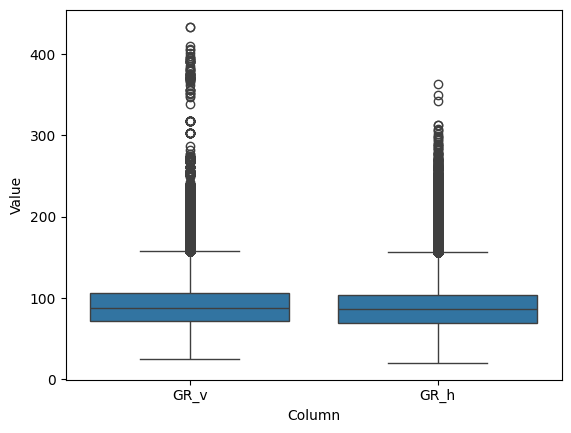

In [9]:
grs = train_df[['GR_v', 'GR_h']].melt(var_name='Column', value_name='Value')
sns.boxplot(grs, x='Column', y = 'Value')

In [10]:
train_df[['X', 'Y', 'Z']].describe()

,X,Y,Z
count,1308266.00,1308266.00,1308266.00
mean,2967537.83,1075336.05,-9283.63
std,46738.40,35326.51,654.97
min,2858892.37,1007175.50,-10841.23
25%,2921677.28,1041347.90,-9797.05
50%,2986783.91,1082701.82,-9164.50
75%,3007407.38,1104753.30,-8809.02
max,3037463.83,1138105.78,-7174.22


In [11]:
test_df.columns

Index(['id', 'MD', 'X', 'Y', 'Z', 'GR_h', 'TVT_input', 'TVT_v', 'GR_v'], dtype='object')

In [12]:
train_df.columns

Index(['id', 'MD', 'X', 'Y', 'Z', 'ANCC', 'ASTNU', 'ASTNL', 'EGFDU', 'EGFDL',
       'BUDA', 'TVT', 'GR_h', 'TVT_input', 'TVT_v', 'GR_v', 'Geology'],
      dtype='object')

# data processing

In [13]:
def data_processing(df): 
    df = df.sort_values(by = ['id', 'MD'])
    df = df.drop(['TVT_input', 'TVT_v'], axis = 1)
    if 'ANCC' in df.columns: 
        df = df.drop(['ANCC', 'ASTNU', 'ASTNL', 'EGFDU', 'EGFDL','BUDA','Geology'], axis = 1)
    # get angle of that well for different MD
    window = 3
    df[['dMD', 'dZ']] = df.groupby('id')[['MD', 'Z']].diff(periods=window)
    df['theta'] = (df['dZ']/df['dMD']).abs()
    df['theta'] = df['theta'].ffill().bfill()
    df[['dMD', 'dZ']] =  df[['dMD', 'dZ']].bfill()
    df = df.drop(['dMD'], axis = 1)
    df['GR_v_rmean'] =  df.groupby('id')['GR_v'].rolling(window=3, min_periods=1).mean().reset_index(level=0, drop=True)
    df['GR_v_rstd'] =  df.groupby('id')['GR_v'].rolling(window=3, min_periods=1).std().reset_index(level=0, drop=True)
    df['GR_h_rmean'] =  df.groupby('id')['GR_h'].rolling(window=3, min_periods=1).mean().reset_index(level=0, drop=True)
    df['GR_h_rstd'] =  df.groupby('id')['GR_h'].rolling(window=3, min_periods=1).std().reset_index(level=0, drop=True)
    df['GR_h'] = df['GR_h'].fillna(-999)
    df['X_rmean'] = df.groupby('id')['X'].rolling(window=3, min_periods=1).std().reset_index(level=0, drop=True)
    df['Y_rmean'] = df.groupby('id')['Y'].rolling(window=3, min_periods=1).std().reset_index(level=0, drop=True)
    df[['GR_v_rmean', 'GR_v_rstd', 'GR_h_rmean', 'GR_h_rstd', 'GR_h', 'X_rmean', 'Y_rmean']] =  df[['GR_v_rmean', 'GR_v_rstd', 'GR_h_rmean', 'GR_h_rstd', 'GR_h', 'X_rmean', 'Y_rmean']].bfill()

    rScaler = RobustScaler()
    mScaler = MinMaxScaler(feature_range=(0, 1))
    num_cols = df.select_dtypes(include='number').columns.tolist()
    
    if 'TVT' in num_cols: num_cols.remove('TVT')
    num_cols.remove('MD')
    df[num_cols] = rScaler.fit_transform(df[num_cols])
    df[num_cols] = mScaler.fit_transform(df[num_cols])

    ids =df['id'].unique()
    id_dict = dict(zip(ids, range(len(ids))))
    df['id'] = df['id'].map(id_dict)
    return df

In [14]:
train_df_p = data_processing(train_df.copy())
test_df_p = data_processing(test_df.copy())

In [15]:
train_df_p.isnull().sum()

id            0
MD            0
X             0
Y             0
Z             0
TVT           0
GR_h          0
GR_v          0
dZ            0
theta         0
GR_v_rmean    0
GR_v_rstd     0
GR_h_rmean    0
GR_h_rstd     0
X_rmean       0
Y_rmean       0
dtype: int64

<Axes: >

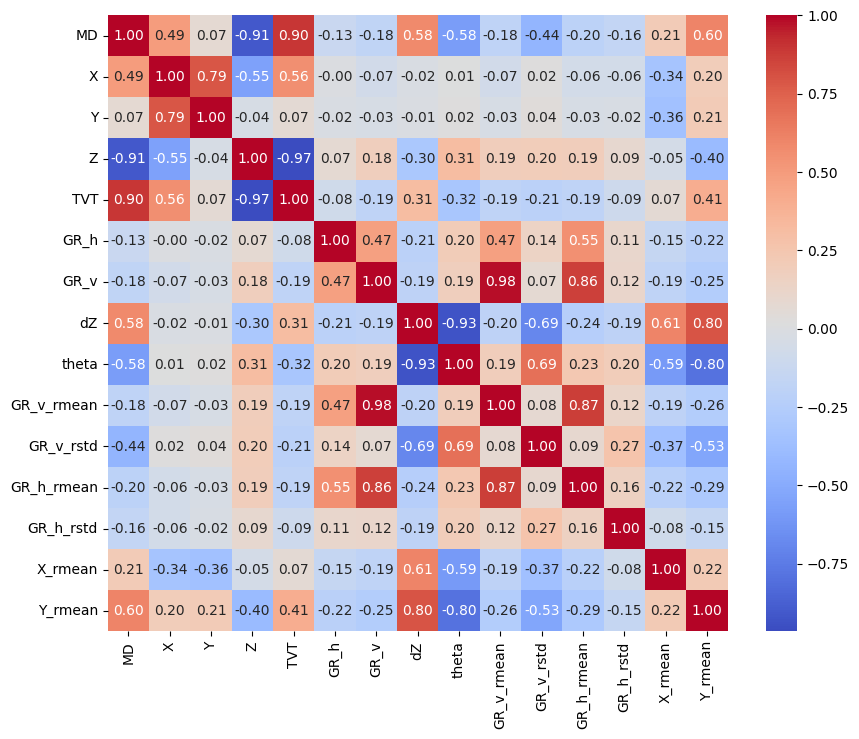

In [16]:
corr_mat = train_df_p.drop('id', axis = 1).corr(method = 'spearman')
plt.figure(figsize = (10,8))
sns.heatmap(corr_mat, cmap = 'coolwarm', annot=True, fmt = '.2f')

# Baseline 
## XGBoost
(note: this task is sequential, so xgboost isn't a good fit, but im just testing the most astray model)

In [17]:
xgb = XGBRegressor()
y = train_df_p.pop('TVT')

groups = train_df_p['id']
cv = GroupKFold()
scores = cross_val_score(xgb, train_df_p, y, cv = cv, groups = groups,  scoring = 'neg_root_mean_squared_error')
scores = -scores
print(scores)
print(sum(scores)/len(scores))

[124.65513026  95.1827106  120.74749862 105.30970312 103.28287394]
109.83558330881888


## One Layer GRU

In [18]:
train_df_p

,id,MD,X,Y,Z,GR_h,GR_v,dZ,theta,GR_v_rmean,GR_v_rstd,GR_h_rmean,GR_h_rstd,X_rmean,Y_rmean
17159,0,11467.00,0.70,0.47,0.43,0.82,0.21,0.02,0.98,0.21,0.01,0.27,0.00,0.01,0.15
17160,0,11468.00,0.70,0.47,0.43,0.82,0.20,0.02,0.98,0.21,0.01,0.27,0.00,0.01,0.15
17161,0,11469.00,0.70,0.47,0.43,0.83,0.22,0.02,0.98,0.21,0.02,0.29,0.09,0.02,0.22
17162,0,11470.00,0.70,0.47,0.43,0.84,0.25,0.02,0.98,0.23,0.05,0.32,0.10,0.02,0.22
17163,0,11471.00,0.70,0.47,0.43,0.82,0.25,0.02,0.97,0.25,0.03,0.31,0.12,0.03,0.22
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
404443,772,13805.00,0.48,0.05,0.02,0.77,0.08,0.81,0.05,0.08,0.00,0.09,0.01,0.25,0.96
404444,772,13806.00,0.48,0.05,0.02,0.78,0.08,0.81,0.05,0.08,0.00,0.09,0.02,0.25,0.96
404445,772,13807.00,0.48,0.05,0.02,0.78,0.08,0.81,0.05,0.08,0.00,0.10,0.01,0.25,0.97
404446,772,13808.00,0.48,0.05,0.02,0.00,0.08,0.81,0.05,0.08,0.00,0.10,0.00,0.25,0.96


In [19]:
q75_mu = train_df_p['id'].quantile(0.75)

In [20]:
def create_manual_windows(df, y_series, id_list, timesteps):
    X_windows = []
    y_targets = []
    # 1. Loop through each unique object to keep timelines completely isolated
    for obj_id in id_list:
        obj_mask = df['id'] == obj_id
        
        # 2. Extract and drop metadata features
        obj_features = df[obj_mask].drop(columns=['id', 'MD']).values
        obj_targets = y_series[obj_mask].values
        
        # 3. Create windows safely within this single object's timeline
        for i in range(len(obj_features) - timesteps):
            X_windows.append(obj_features[i : i + timesteps])
            
            # CRITICAL FIX: Extract only the single target value right AFTER the window
            y_targets.append(obj_targets[i + timesteps])
            
    return np.array(X_windows), np.array(y_targets)

In [21]:
train_df_p.groupby('id').size().describe()

count    773.00
mean    1692.45
std      217.34
min      851.00
25%     1546.00
50%     1703.00
75%     1839.00
max     2392.00
dtype: float64

In [22]:
gkf = GroupKFold(n_splits=5)
scores = []

timestep = 30
for fold, (train_idx, val_idx) in enumerate(gkf.split(train_df_p, y, groups=groups)):
    X_train, X_val = train_df_p.loc[train_idx], train_df_p.loc[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]

    X_train, y_train = create_manual_windows(X_train, y_train, X_train.id.unique(), timestep)
    X_val, y_val = create_manual_windows(X_val, y_val, X_val.id.unique(), timestep)
    
    model = Sequential(
        [
            Input(shape = (timestep, X_train.shape[2])), 
            Conv1D(128, kernel_size=3, activation='relu', kernel_regularizer=regularizers.l1_l2(l1=0.01, l2=0.01),), 
            MaxPooling1D(pool_size=3),
            GRU(128, return_sequences=False, dropout = 0.3),
            Dense(1, activation='linear')
        ]
    )
    model.compile(optimizer='adam', loss='mean_squared_error')

    early_stopping = tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',     
        patience=3,          
        restore_best_weights=True 
    )
    keras.utils.set_random_seed(42)
    history = model.fit(X_train, 
          y_train,  
          validation_data=(X_val, y_val),
          epochs=50, 
          verbose=1,  
          callbacks=[early_stopping],
          shuffle = True)
    loss = min(history.history['val_loss'])
    scores.append(np.sqrt(loss))
    print(np.sqrt(loss))

print(f"\nAverage Cross-Validation RMSE across all groups: {np.mean(scores):.4f}")


2026-06-05 05:16:37.270145: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Epoch 1/50
32007/32007 ━━━━━━━━━━━━━━━━━━━━ 291s 9ms/step - loss: 108472840.0000 - val_loss: 53767052.0000
Epoch 2/50
32007/32007 ━━━━━━━━━━━━━━━━━━━━ 291s 9ms/step - loss: 40788524.0000 - val_loss: 11191246.0000
Epoch 3/50
32007/32007 ━━━━━━━━━━━━━━━━━━━━ 294s 9ms/step - loss: 6433175.5000 - val_loss: 477497.1875
Epoch 4/50
32007/32007 ━━━━━━━━━━━━━━━━━━━━ 293s 9ms/step - loss: 424155.0938 - val_loss: 477506.0625
Epoch 5/50
32007/32007 ━━━━━━━━━━━━━━━━━━━━ 294s 9ms/step - loss: 424155.7812 - val_loss: 477506.0625
Epoch 6/50
32007/32007 ━━━━━━━━━━━━━━━━━━━━ 300s 9ms/step - loss: 416645.6250 - val_loss: 46941.1016
Epoch 7/50
32007/32007 ━━━━━━━━━━━━━━━━━━━━ 294s 9ms/step - loss: 25521.0371 - val_loss: 17541.6797
Epoch 8/50
32007/32007 ━━━━━━━━━━━━━━━━━━━━ 285s 9ms/step - loss: 13731.0098 - val_loss: 15819.6729
Epoch 9/50
32007/32007 ━━━━━━━━━━━━━━━━━━━━ 297s 9ms/step - loss: 11559.8721 - val_loss: 15867.3730
Epoch 10/50
32007/32007 ━━━━━━━━━━━━━━━━━━━━ 290s 9ms/step - loss: 9996.3477 - 